<a href="https://colab.research.google.com/github/John-588-git/Dashboard/blob/main/text_representation_practical_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

# Install gensim if not already installed
!pip install gensim
from gensim.models import Word2Vec

#load the data set
# Check if 'preprocessed_data.csv' exists, if not, create a dummy one.
try:
    df = pd.read_csv("preprocessed_data.csv")
    print("Loaded 'preprocessed_data.csv' successfully.")
except FileNotFoundError:
    print("preprocessed_data.csv not found. Creating a dummy file for demonstration.")
    dummy_data = {
        'text': [
            'computer science is useful',
            'machine learning uses matrices',
            'natural language processing analyzes text',
            'computer science and machine learning',
            'text classification uses machine learning'
        ]
    }
    df = pd.DataFrame(dummy_data)
    df.to_csv("preprocessed_data.csv", index=False)
    print("Dummy 'preprocessed_data.csv' created.")

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nFirst five records:")
display(df.head())
#check for the missing values
print("\nMissing values:")
print(df.isnull().sum())

#remove the missing text
df = df.dropna(subset=["text"]).copy()

# Make sure text is stored as string
df["text"] = df["text"].astype(str)

print("Number of documents:", len(df))

Loaded 'preprocessed_data.csv' successfully.
Dataset shape: (5, 1)

Column names:
Index(['text'], dtype='object')

First five records:


,text
0,computer science is useful
1,machine learning uses matrices
2,natural language processing analyzes text
3,computer science and machine learning
4,text classification uses machine learning



Missing values:
text    0
dtype: int64
Number of documents: 5


BoW matrix shape: (5, 15)
BoW Vocabulary:
['analyzes' 'and' 'classification' 'computer' 'is' 'language' 'learning'
 'machine' 'matrices' 'natural' 'processing' 'science' 'text' 'useful'
 'uses']


,analyzes,and,classification,computer,is,language,learning,machine,matrices,natural,processing,science,text,useful,uses
0,0,0,0,1,1,0,0,0,0,0,0,1,0,1,0
1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,1
2,1,0,0,0,0,1,0,0,0,1,1,0,1,0,0
3,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0
4,0,0,1,0,0,0,1,1,0,0,0,0,1,0,1


Most frequent words:


,0
learning,3
machine,3
computer,2
science,2
text,2
uses,2
analyzes,1
language,1
is,1
and,1


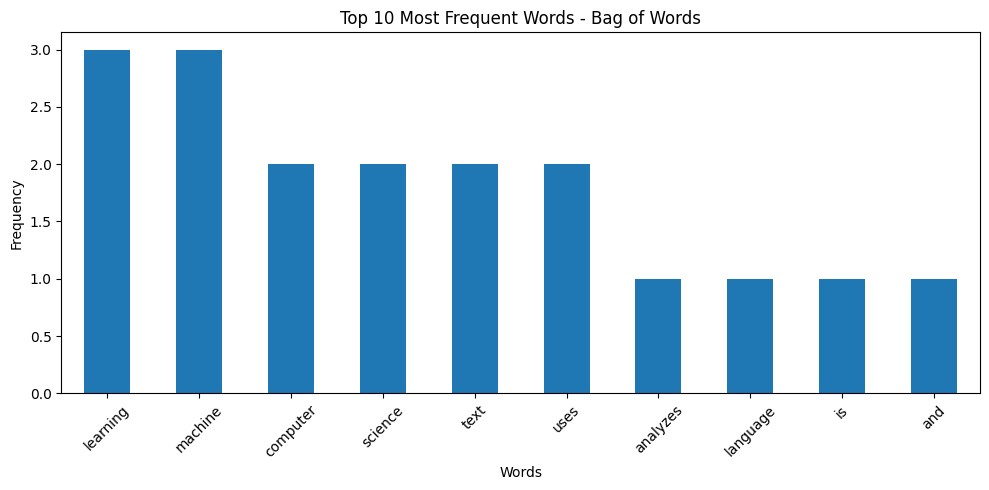

In [9]:
#2. TASK TWO Implement BoW and TF-IDF using Python (scikit-learn).

#Create the BoW model
bow_vectorizer = CountVectorizer()

bow_matrix = bow_vectorizer.fit_transform(df["text"])

print("BoW matrix shape:", bow_matrix.shape)
#DISPLAY THE VOCABULARY
bow_features = bow_vectorizer.get_feature_names_out()

print("BoW Vocabulary:")
print(bow_features)
#CONVERT MATRIX TO DATA FRAME
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=bow_features
)

display(bow_df.head())
#DISPLAY THE MOST FREQUENT WORD
word_counts = bow_df.sum(axis=0).sort_values(ascending=False)

print("Most frequent words:")
display(word_counts.head(10))
#VISULISE THE MOST FREQUENT BoW WORDS
plt.figure(figsize=(10, 5))

word_counts.head(10).plot(kind="bar")

plt.title("Top 10 Most Frequent Words - Bag of Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

TF-IDF matrix shape: (5, 15)
TF-IDF Vocabulary:
['analyzes' 'and' 'classification' 'computer' 'is' 'language' 'learning'
 'machine' 'matrices' 'natural' 'processing' 'science' 'text' 'useful'
 'uses']


,analyzes,and,classification,computer,is,language,learning,machine,matrices,natural,processing,science,text,useful,uses
0,0.000000,0.000000,0.000000,0.444002,0.550329,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.444002,0.000000,0.550329,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.419559,0.419559,0.626477,0.000000,0.000000,0.000000,0.000000,0.000000,0.505438
2,0.463693,0.000000,0.000000,0.000000,0.000000,0.463693,0.000000,0.000000,0.000000,0.463693,0.463693,0.000000,0.374105,0.000000,0.000000
3,0.000000,0.559117,0.000000,0.451092,0.000000,0.000000,0.374447,0.374447,0.000000,0.000000,0.000000,0.451092,0.000000,0.000000,0.000000
4,0.000000,0.000000,0.559117,0.000000,0.000000,0.000000,0.374447,0.374447,0.000000,0.000000,0.000000,0.000000,0.451092,0.000000,0.451092


Top words according to TF-IDF:


,0
learning,1.168453
machine,1.168453
uses,0.956529
computer,0.895094
science,0.895094
text,0.825197
matrices,0.626477
and,0.559117
classification,0.559117
is,0.550329


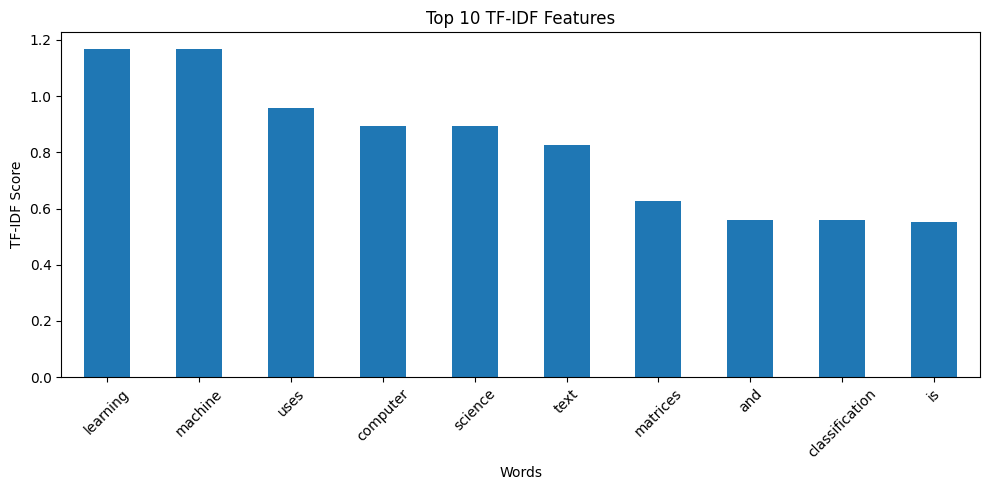

In [10]:
# TASK THREE: IMPLEMENTING TF-IDF
#Create the TF-IDF model
tfidf_vectorizer = TfidfVectorizer()

tfidf_matrix = tfidf_vectorizer.fit_transform(df["text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
#GET THE VOCABULARY
tfidf_features = tfidf_vectorizer.get_feature_names_out()

print("TF-IDF Vocabulary:")
print(tfidf_features)
#CONVERT TO A DATAFRAME
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_features
)

display(tfidf_df.head())
#Find words with the highest TF-IDF scores
tfidf_scores = tfidf_df.sum(axis=0).sort_values(ascending=False)

print("Top words according to TF-IDF:")
display(tfidf_scores.head(10))
#Visualizing TF-IDF features
plt.figure(figsize=(10, 5))

tfidf_scores.head(10).plot(kind="bar")

plt.title("Top 10 TF-IDF Features")
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
#TASK 4: USE A PRE-TRAINED/EMBENDING MODEL — Word2Vec
#a) tokenize sentenses
tokenized_sentences = [
    sentence.lower().split()
    for sentence in df["text"]
]

print(tokenized_sentences[:5])
#b)train word2vec
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    seed=42
)

print("Word2Vec model created successfully.")
#c)check vocabulary
print("Number of words in Word2Vec vocabulary:",
      len(word2vec_model.wv.key_to_index))
#d) display the vector of words
word = word2vec_model.wv.index_to_key[0]

print("Selected word:", word)

print("\nWord vector:")
print(word2vec_model.wv[word])
#e)vector size
vector_size=100
#f)finding similar words
word = word2vec_model.wv.index_to_key[0]

print("Selected word:", word)

print("\nSimilar words:")
print(word2vec_model.wv.most_similar(word, topn=5))


[['computer', 'science', 'is', 'useful'], ['machine', 'learning', 'uses', 'matrices'], ['natural', 'language', 'processing', 'analyzes', 'text'], ['computer', 'science', 'and', 'machine', 'learning'], ['text', 'classification', 'uses', 'machine', 'learning']]
Word2Vec model created successfully.
Number of words in Word2Vec vocabulary: 15
Selected word: learning

Word vector:
[-8.2149813e-03  5.4791202e-03  3.0914294e-03 -1.2224317e-03
 -1.3396954e-03  7.1719573e-03 -8.2810875e-03  3.9473604e-03
 -5.9706103e-03 -8.1164539e-03  5.2957895e-04  9.5124459e-03
  4.7150468e-03  5.2227937e-03  4.3495451e-03  5.7212855e-03
  2.6453138e-04 -7.4377274e-03  6.7949640e-03 -9.9228148e-04
  7.0381166e-06 -2.5840402e-03 -6.3490081e-03  8.5352995e-03
  5.6313490e-03  2.8773022e-03 -1.9517136e-03  6.4552319e-03
  9.0858224e-04 -1.1317170e-03 -9.9080917e-04 -5.4552257e-03
 -8.1572821e-03  1.0916948e-03  7.7577960e-03 -8.7236557e-03
  7.1658255e-03  6.5526222e-03 -4.4648065e-03  2.6332878e-03
 -6.6954195e

Word2Vec document vectors shape: (5, 100)


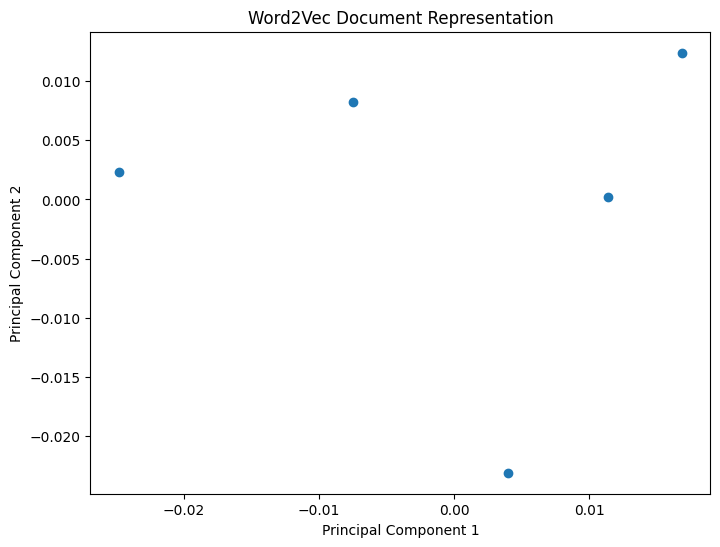

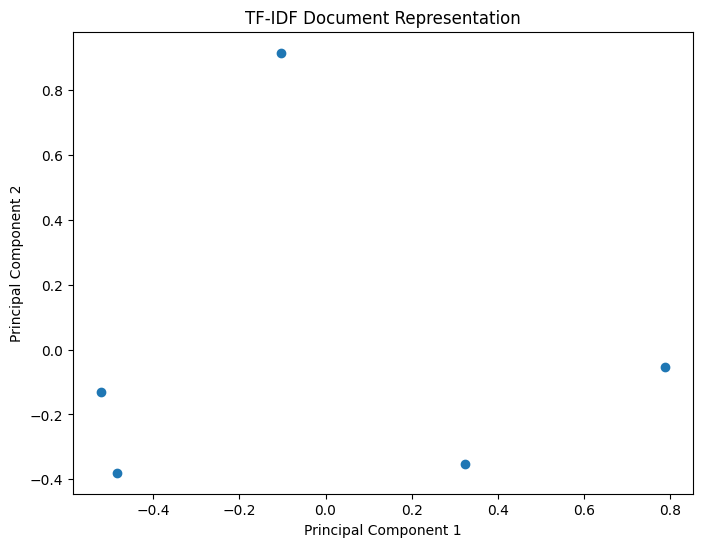

,Method,Number_of_documents,Number_of_features
0,BoW,5,15
1,TF-IDF,5,15
2,Word2Vec,5,100


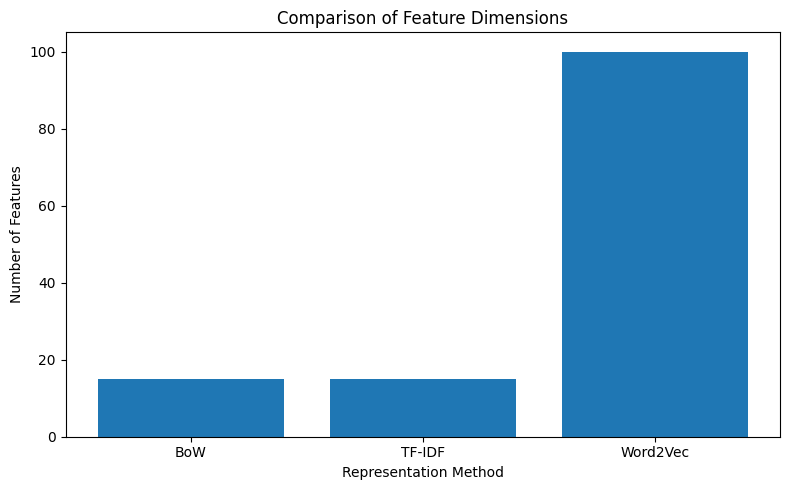

In [13]:
# OBJECTIVE NUMBER 4. Visualize and compare features.
# Helper function to average word vectors for a document
def document_vector(word2vec_model, doc):
    # Remove out-of-vocabulary words
    doc = [word for word in doc if word in word2vec_model.wv.key_to_index]
    if doc:
        return np.mean(word2vec_model.wv[doc], axis=0)
    else:
        return np.zeros(word2vec_model.vector_size)

# Create document vectors for Word2Vec
word2vec_vectors = np.array([
    document_vector(word2vec_model, sentence)
    for sentence in tokenized_sentences
])

print("Word2Vec document vectors shape:", word2vec_vectors.shape)

#A)VISUALISE WORD2VEC
pca = PCA(n_components=2)

word2vec_2d = pca.fit_transform(word2vec_vectors)

plt.figure(figsize=(8, 6))

plt.scatter(
    word2vec_2d[:, 0],
    word2vec_2d[:, 1]
)

plt.title("Word2Vec Document Representation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()
#B)VISUALIZE TD-IDF
pca_tfidf = PCA(n_components=2)

tfidf_2d = pca_tfidf.fit_transform(
    tfidf_matrix.toarray()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    tfidf_2d[:, 0],
    tfidf_2d[:, 1]
)

plt.title("TF-IDF Document Representation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()
#C)Compare BoW, TF-IDF and Word2Vec
comparison = pd.DataFrame({
    "Method": ["BoW", "TF-IDF", "Word2Vec"],
    "Number_of_documents": [
        bow_matrix.shape[0],
        tfidf_matrix.shape[0],
        word2vec_vectors.shape[0]
    ],
    "Number_of_features": [
        bow_matrix.shape[1],
        tfidf_matrix.shape[1],
        word2vec_vectors.shape[1]
    ]
})

display(comparison)
#D) FEATURE DIMENSION COMPARISON
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Method"],
    comparison["Number_of_features"]
)

plt.title("Comparison of Feature Dimensions")
plt.xlabel("Representation Method")
plt.ylabel("Number of Features")

plt.tight_layout()
plt.show()

In [14]:
#SUMMARY TABLE
summary = pd.DataFrame({
    "Technique": [
        "Bag of Words",
        "TF-IDF",
        "Word2Vec"
    ],
    "Representation": [
        "Word frequency/count",
        "Importance of words in documents",
        "Dense semantic word vectors"
    ],
    "Advantages": [
        "Simple and easy to interpret",
        "Reduces importance of common words",
        "Captures semantic relationships"
    ],
    "Disadvantages": [
        "Ignores word meaning and order",
        "Produces sparse high-dimensional features",
        "Requires more computation and training data"
    ]
})

display(summary)

,Technique,Representation,Advantages,Disadvantages
0,Bag of Words,Word frequency/count,Simple and easy to interpret,Ignores word meaning and order
1,TF-IDF,Importance of words in documents,Reduces importance of common words,Produces sparse high-dimensional features
2,Word2Vec,Dense semantic word vectors,Captures semantic relationships,Requires more computation and training data
